Load the train and test datasets

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from src.preprocessing import preprocess_complaint


train_df = pd.read_parquet("../data/processed/train_complaints.parquet")
test_df  = pd.read_parquet("../data/processed/test_complaints.parquet")

print(train_df.shape)
print(test_df.shape)

(812720, 4)
(203180, 4)


Define features and targets

In [2]:
X_train = train_df["Consumer complaint narrative"]
X_test  = test_df["Consumer complaint narrative"]

y_train_dept = train_df["Department"]
y_test_dept  = test_df["Department"]

y_train_priority = train_df["Priority"]
y_test_priority  = test_df["Priority"]

Department classification pipeline (NB)

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

department_pipeline_NB = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor= preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", MultinomialNB())
])

Train Department Model

In [5]:
department_pipeline_NB.fit(X_train, y_train_dept)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...t 0x10e9ba5c0>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Priority classification pipeline (NB)

In [6]:
priority_pipeline_NB = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", MultinomialNB())
])

priority_pipeline_NB.fit(X_train, y_train_priority)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...t 0x10e9ba660>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Predictions (NB)

In [9]:
dept_preds = department_pipeline_NB.predict(X_test)
priority_preds = priority_pipeline_NB.predict(X_test)

Model Evaluation - Departmental (NB)

In [11]:
from sklearn.metrics import accuracy_score, classification_report

print("Department Model Accuracy:")
print(accuracy_score(y_test_dept, dept_preds))

print("\nDepartment Classification Report:")
print(classification_report(y_test_dept, dept_preds))

Department Model Accuracy:
0.8188010630967615

Department Classification Report:
                         precision    recall  f1-score   support

          Bank accounts       0.67      0.87      0.76     13452
          Card services       0.60      0.79      0.68     16340
         Consumer loans       0.60      0.61      0.60      4266
       Credit reporting       0.94      0.86      0.90    118439
        Debt collection       0.70      0.74      0.72     26505
Money transfer services       0.91      0.50      0.65      6765
               Mortgage       0.75      0.94      0.83     10507
Payday / personal loans       0.74      0.16      0.27      2473
           Student loan       0.75      0.82      0.78      4433

               accuracy                           0.82    203180
              macro avg       0.74      0.70      0.69    203180
           weighted avg       0.84      0.82      0.82    203180



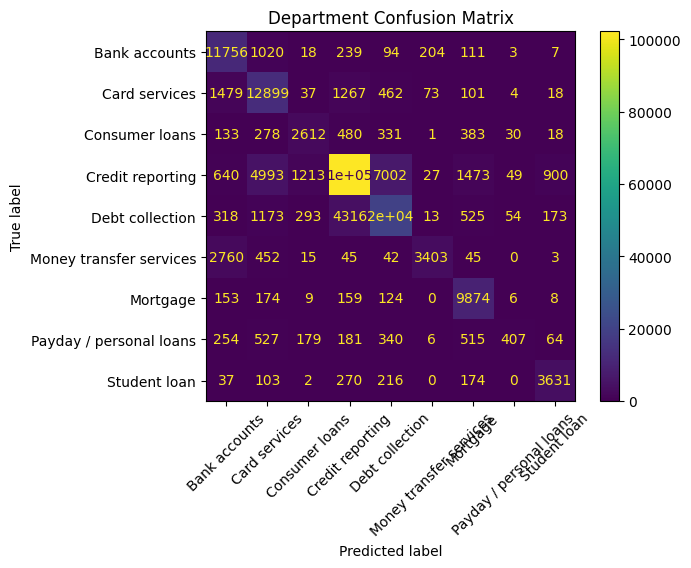

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_dept,
    dept_preds,
    xticks_rotation=45
)

plt.title("Department Confusion Matrix")
plt.show()

Model Evaluation - Priority (NB)

In [14]:
print("Priority Model Accuracy:")
print(accuracy_score(y_test_priority, priority_preds))

print("\nPriority Classification Report:")
print(classification_report(y_test_priority, priority_preds))

Priority Model Accuracy:
0.6128162220691012

Priority Classification Report:
               precision    recall  f1-score   support

     critical       0.62      0.57      0.59     51184
high_priority       0.60      0.34      0.44     67473
     standard       0.61      0.85      0.71     84523

     accuracy                           0.61    203180
    macro avg       0.61      0.59      0.58    203180
 weighted avg       0.61      0.61      0.59    203180



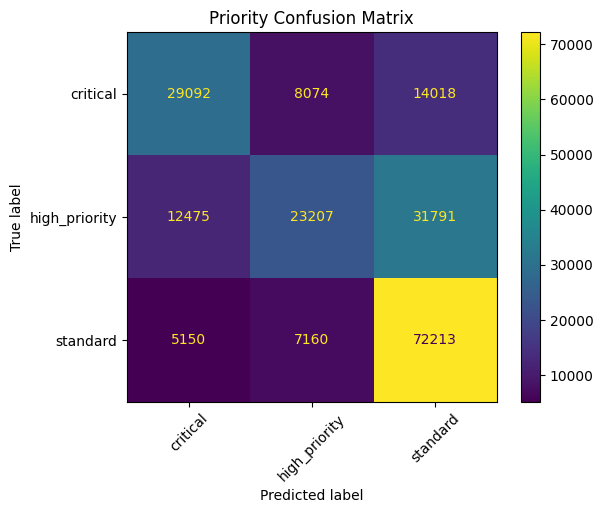

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test_priority,
    priority_preds,
    xticks_rotation=45
)

plt.title("Priority Confusion Matrix")
plt.show()

Departmental classification pipeline (LR)

In [17]:
from sklearn.linear_model import LogisticRegression

dept_pipeline__2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
    ))
])

dept_pipeline__2.fit(X_train, y_train_dept)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...t 0x10e9ba5c0>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Priority classification pipeline (LR)

In [18]:
priority_pipeline__2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
    ))
])

priority_pipeline__2.fit(X_train, y_train_priority)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...t 0x10e9ba660>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [19]:
dept_preds_2 = dept_pipeline__2.predict(X_test)
priority_preds_2 = priority_pipeline__2.predict(X_test)

Model evaluation - Departmental (LR)

In [20]:
print("Department Model (Logistic Regression)")

print("\nAccuracy:")
print(accuracy_score(y_test_dept, dept_preds_2))

print("\nClassification Report:")
print(classification_report(y_test_dept, dept_preds_2))

Department Model (Logistic Regression)

Accuracy:
0.8726892410670342

Classification Report:
                         precision    recall  f1-score   support

          Bank accounts       0.79      0.84      0.81     13452
          Card services       0.80      0.78      0.79     16340
         Consumer loans       0.74      0.62      0.67      4266
       Credit reporting       0.91      0.95      0.93    118439
        Debt collection       0.80      0.73      0.76     26505
Money transfer services       0.82      0.74      0.78      6765
               Mortgage       0.90      0.90      0.90     10507
Payday / personal loans       0.66      0.47      0.55      2473
           Student loan       0.88      0.79      0.83      4433

               accuracy                           0.87    203180
              macro avg       0.81      0.76      0.78    203180
           weighted avg       0.87      0.87      0.87    203180



Model evaluation - Priority (LR)

In [21]:
print("Priority Model (Logistic Regression)")

print("\nAccuracy:")
print(accuracy_score(y_test_priority, priority_preds_2))

print("\nClassification Report:")
print(classification_report(y_test_priority, priority_preds_2))

Priority Model (Logistic Regression)

Accuracy:
0.7879761787577517

Classification Report:
               precision    recall  f1-score   support

     critical       0.83      0.77      0.80     51184
high_priority       0.70      0.69      0.69     67473
     standard       0.83      0.88      0.86     84523

     accuracy                           0.79    203180
    macro avg       0.79      0.78      0.78    203180
 weighted avg       0.79      0.79      0.79    203180



Logestic Regression with class balance

In [22]:
dept_pipeline__LR = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

dept_pipeline__LR.fit(X_train, y_train_dept)

priority_pipeline__LR = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

priority_pipeline__LR.fit(X_train, y_train_priority)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...t 0x10e9ba660>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Prediction

In [23]:
dept_preds_LR = dept_pipeline__LR.predict(X_test)
priority_preds_LR = priority_pipeline__LR.predict(X_test)

Model Evaluation

In [24]:
# Departmental model
print("Department Model (Logistic Regression)")

print("\nAccuracy:")
print(accuracy_score(y_test_dept, dept_preds_LR))

print("\nClassification Report:")
print(classification_report(y_test_dept, dept_preds_LR))

# Priority model
print("Priority Model (Logistic Regression)")

print("\nAccuracy:")
print(accuracy_score(y_test_priority, priority_preds_LR))

print("\nClassification Report:")
print(classification_report(y_test_priority, priority_preds_LR))

Department Model (Logistic Regression)

Accuracy:
0.8318732158677035

Classification Report:
                         precision    recall  f1-score   support

          Bank accounts       0.77      0.81      0.79     13452
          Card services       0.71      0.81      0.75     16340
         Consumer loans       0.45      0.78      0.57      4266
       Credit reporting       0.97      0.84      0.90    118439
        Debt collection       0.69      0.80      0.74     26505
Money transfer services       0.73      0.81      0.77      6765
               Mortgage       0.85      0.93      0.89     10507
Payday / personal loans       0.34      0.68      0.46      2473
           Student loan       0.70      0.90      0.79      4433

               accuracy                           0.83    203180
              macro avg       0.69      0.82      0.74    203180
           weighted avg       0.86      0.83      0.84    203180

Priority Model (Logistic Regression)

Accuracy:
0.784713062

Confusion Matrix

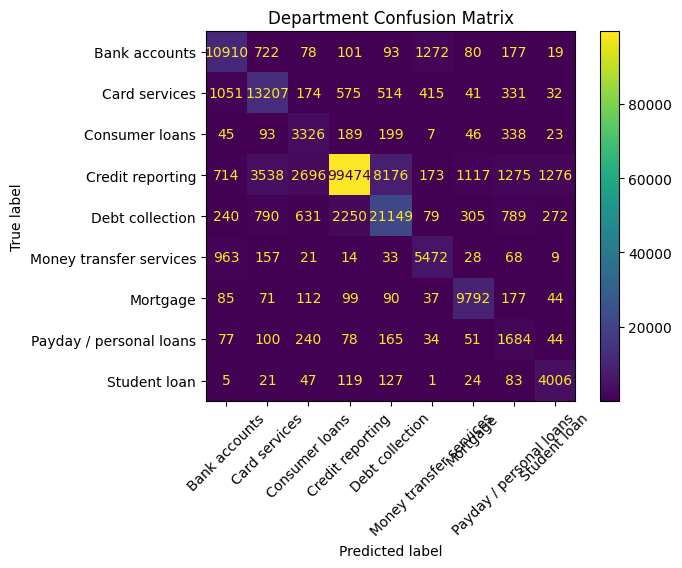

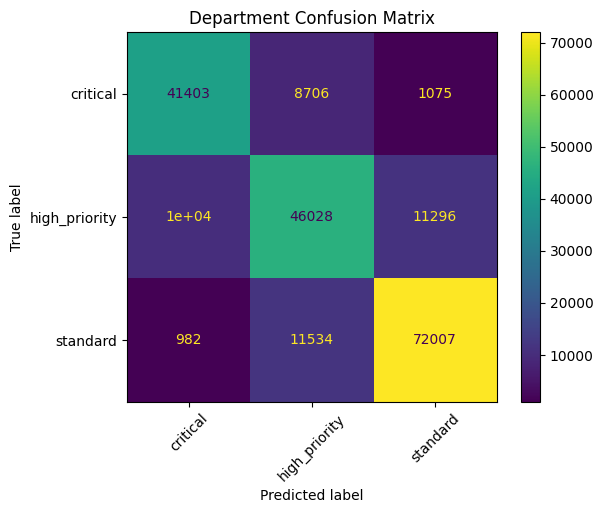

In [25]:
# Departmental model
ConfusionMatrixDisplay.from_predictions(
    y_test_dept,
    dept_preds_LR,
    xticks_rotation=45
)

plt.title("Department Confusion Matrix")
plt.show()

#Priority Model
ConfusionMatrixDisplay.from_predictions(
    y_test_priority,
    priority_preds_LR,
    xticks_rotation=45
)

plt.title("Department Confusion Matrix")
plt.show()

Linear SVM model

In [3]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.calibration import CalibratedClassifierCV

dept_pipeline__SVM = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", CalibratedClassifierCV(LinearSVC(
        class_weight="balanced"
    )))
])

dept_pipeline__SVM.fit(X_train, y_train_dept)

priority_pipeline__SVM = Pipeline([
    ("tfidf", TfidfVectorizer(
        preprocessor=preprocess_complaint,
        stop_words="english",
        ngram_range=(1,2),
        max_features=50000,
        min_df=5
    )),
    ("clf", CalibratedClassifierCV(LinearSVC(
        class_weight="balanced"
    )))
])

priority_pipeline__SVM.fit(X_train, y_train_priority)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function pre...t 0x10cfc2660>
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Prediction and Evaluation

In [6]:
from sklearn.metrics import accuracy_score, classification_report
# Department predictions + evaluation
y_pred_dept = dept_pipeline__SVM.predict(X_test)
print("Department Classification Report:\n", classification_report(y_test_dept, y_pred_dept))

# Priority predictions + evaluation
y_pred_priority = priority_pipeline__SVM.predict(X_test)
print("\nPriority Classification Report:\n", classification_report(y_test_priority, y_pred_priority))

Department Classification Report:
                          precision    recall  f1-score   support

          Bank accounts       0.78      0.82      0.80     13452
          Card services       0.79      0.76      0.78     16340
         Consumer loans       0.71      0.58      0.64      4266
       Credit reporting       0.91      0.94      0.93    118439
        Debt collection       0.79      0.73      0.76     26505
Money transfer services       0.81      0.74      0.77      6765
               Mortgage       0.89      0.90      0.90     10507
Payday / personal loans       0.67      0.39      0.49      2473
           Student loan       0.86      0.79      0.83      4433

               accuracy                           0.87    203180
              macro avg       0.80      0.74      0.77    203180
           weighted avg       0.86      0.87      0.86    203180


Priority Classification Report:
                precision    recall  f1-score   support

     critical       0.79   

In [7]:
import joblib

# save priority model
joblib.dump(priority_pipeline__SVM, "../models/priority_model.joblib")

# save department model
joblib.dump(dept_pipeline__SVM, "../models/department_model.joblib")

['../models/department_model.joblib']